In [ ]:
dir(models)

In [1]:
import torch
import fastai
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from fastai.vision.all import *
from fastai.vision.augment import *
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [2]:

fields = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
)

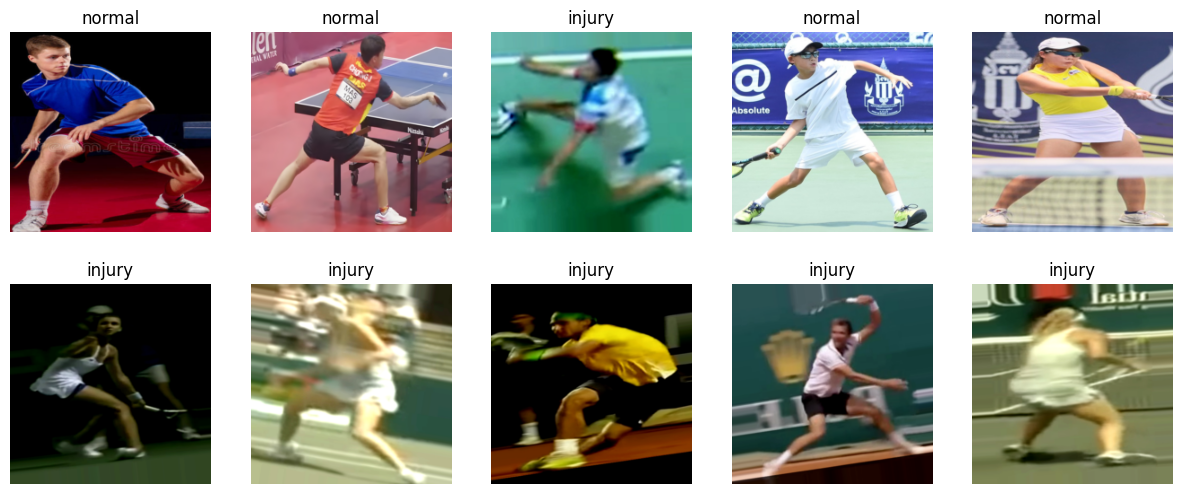

In [3]:
fields = fields.new(item_tfms=Resize(224, method=ResizeMethod.Squish))
# dls = fields.dataloaders("/content/gdrive/MyDrive/data3/tr")
dls = fields.dataloaders("/content/drive/MyDrive/trainv3/")
dls.train.show_batch(max_n=10,nrows=2)

In [ ]:
fields = fields.new(item_tfms=Resize(200, method=ResizeMethod.Squish),batch_tfms=aug_transforms(p_lighting=1.0,p_affine=1.0,max_warp=0,max_lighting=0.4,min_zoom=1,max_zoom=1,max_rotate=10.0))
dls = fields.dataloaders("/content/gdrive/MyDrive/data/tr")
dls.train.show_batch(max_n=10,nrows=2,unique=True)

In [ ]:
# dls = fields.dataloaders("/content/gdrive/MyDrive/Colab Notebooks/data/tr/")
# dls = fields.dataloaders("/content/gdrive/MyDrive/data/tr")

In [ ]:
# get_image_files('/content/gdrive/MyDrive/Colab Notebooks/data/tr/')
get_image_files("/content/gdrive/MyDrive/data2/tr")

(#971) [Path('/content/gdrive/MyDrive/data2/tr/injury/aug_6_1180019.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_35_8934211.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_45_204059.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_38_3064121.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_9_8461194.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_4_8944949.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_78_4507960.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_12_8278741.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_72_3611470.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_18_9908892.png')...]

In [ ]:
dls.vocab

['injury', 'normal']

In [ ]:
dls.train.show_batch(max_n=100, nrows=9)

In [ ]:
dls.valid.show_batch(max_n=100, nrows=9)

In [4]:
learner = vision_learner(dls, swin_t, metrics=[error_rate, accuracy,Precision(),Recall(),F1Score(),RocAucBinary()])

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth
100%|██████████| 108M/108M [00:01<00:00, 91.8MB/s]


In [ ]:
learner.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 96 x 56 x 56   
Conv2d                                    4704       False     
____________________________________________________________________________
                     64 x 56 x 56 x 96   
Permute                                                        
LayerNorm                                 192        True      
LayerNorm                                 192        True      
StochasticDepth                                                
LayerNorm                                 192        True      
____________________________________________________________________________
                     64 x 56 x 56 x 384  
Linear                                    37248      False     
GELU                                                           
Dropout                                                        
___________________________________

In [5]:
import time

SuggestedLRs(valley=0.0014454397605732083)

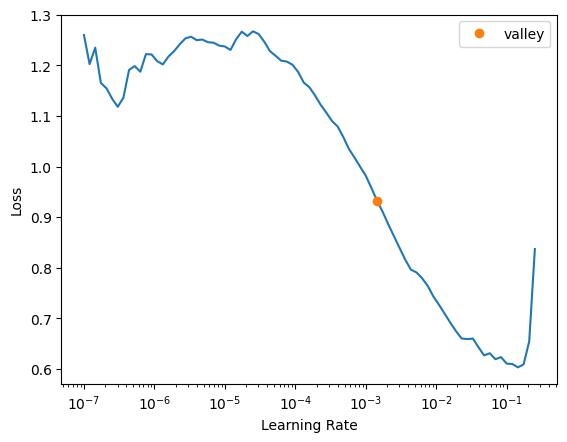

In [ ]:
learner.lr_find()

In [6]:
t0 = time.time()
learner.fine_tune(epochs=25, base_lr=0.0004 ,freeze_epochs=0 ) #12:51 0.997494
print("Training time:", time.time()-t0)

epoch,train_loss,valid_loss,error_rate,accuracy,precision_score,recall_score,f1_score,roc_auc_score,time
0,0.898658,0.381494,0.168865,0.831135,0.791262,0.885870,0.835897,0.919259,03:14
1,0.726955,0.204008,0.073879,0.926121,0.890000,0.967391,0.927083,0.978010,00:48
2,0.554233,0.121769,0.031662,0.968338,0.947917,0.989130,0.968085,0.992670,00:53
3,0.422913,0.074989,0.031662,0.968338,0.947917,0.989130,0.968085,0.997575,00:50
4,0.318916,0.053203,0.018470,0.981530,0.968254,0.994565,0.981233,0.998662,00:49
5,0.251528,0.034552,0.010554,0.989446,0.983871,0.994565,0.989189,0.999693,00:48
6,0.207521,0.022166,0.005277,0.994723,0.989247,1.000000,0.994595,0.999889,00:48
7,0.160949,0.018314,0.002639,0.997361,0.994595,1.000000,0.997290,0.999944,00:51
8,0.133554,0.011833,0.002639,0.997361,0.994595,1.000000,0.997290,1.000000,00:50
9,0.112440,0.009785,0.002639,0.997361,0.994595,1.000000,0.997290,1.000000,00:51


Training time: 1393.434289932251


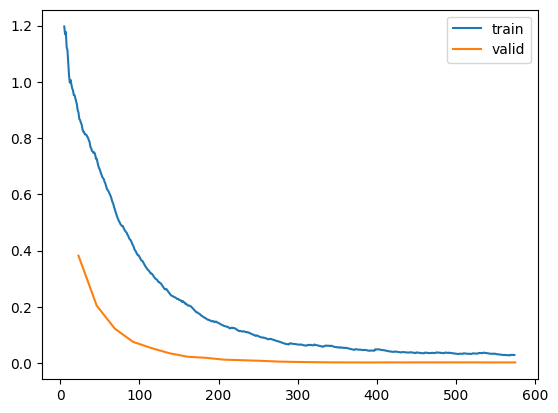

In [7]:
learner.recorder.plot_loss()

In [8]:
@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()

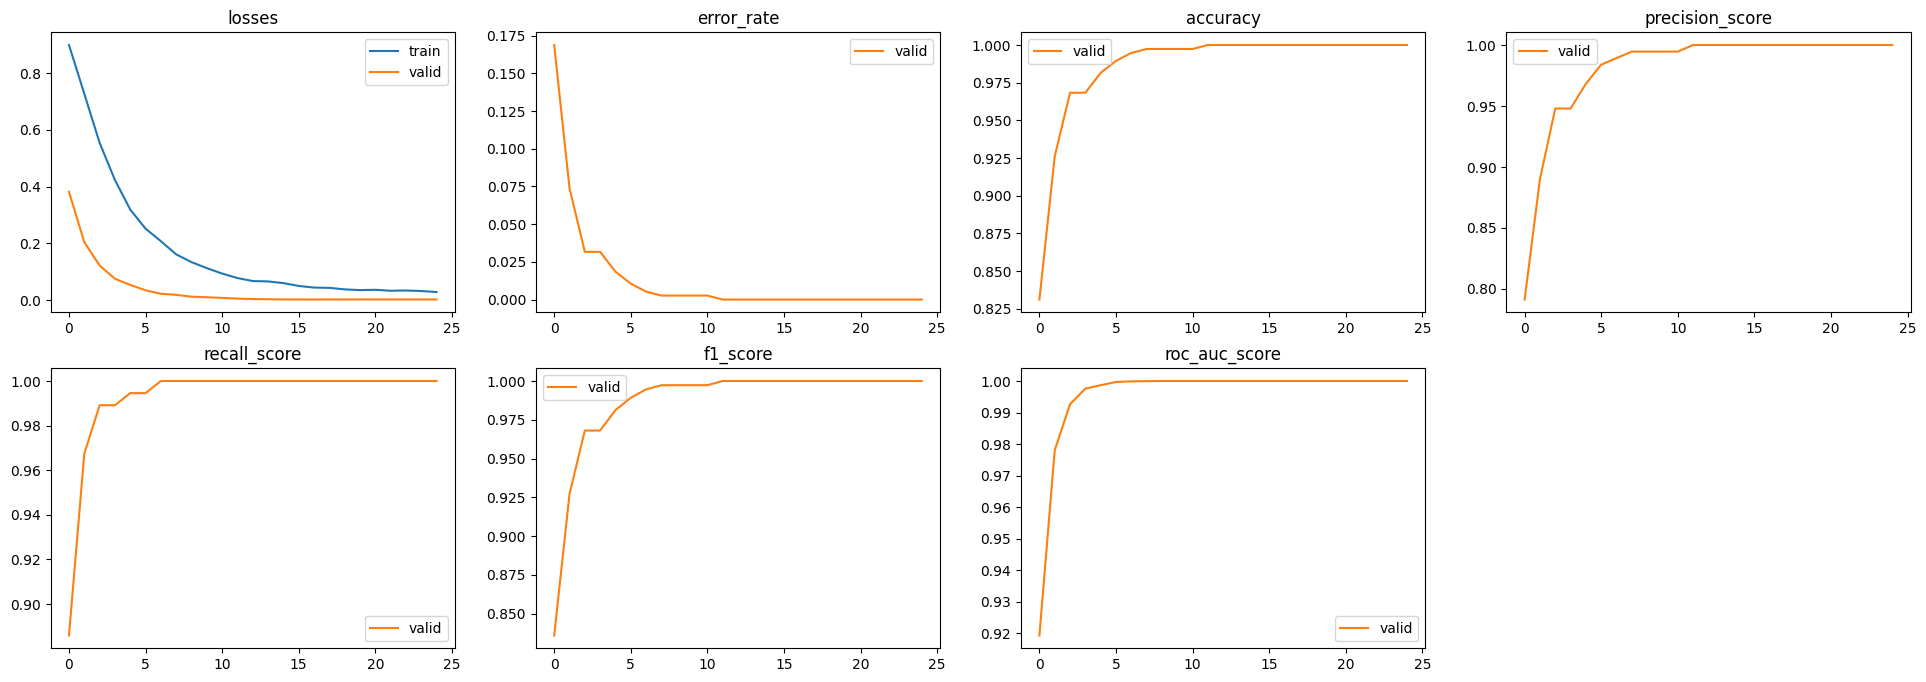

In [9]:
learner.recorder.plot_metrics()

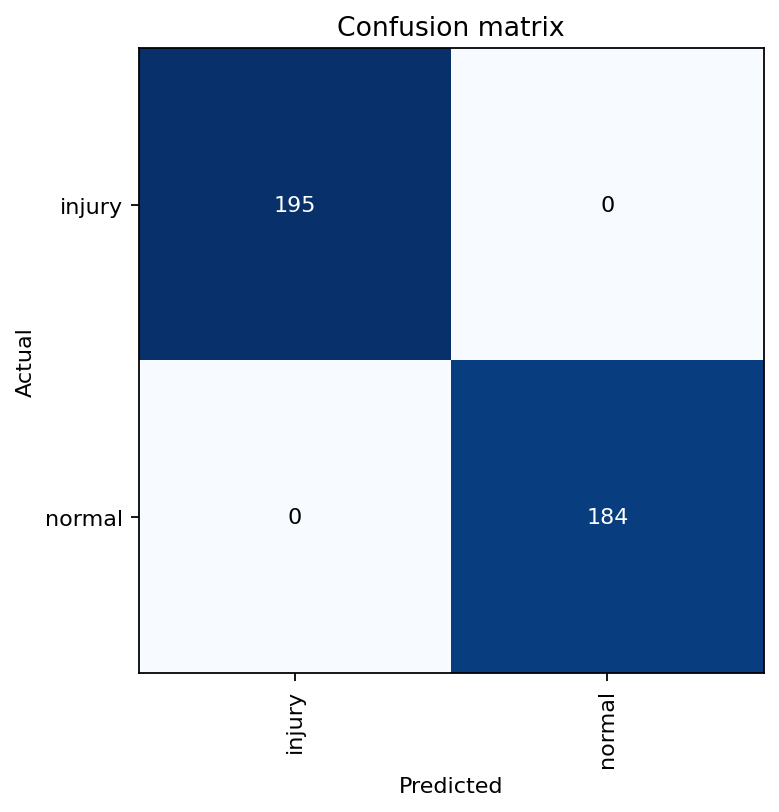

In [10]:
interp = ClassificationInterpretation.from_learner(learner)
interp.plot_confusion_matrix(figsize=(5,5), dpi=160)

In [ ]:
interp.plot_top_losses(2, figsize=(5,5))

ValueError: ignored

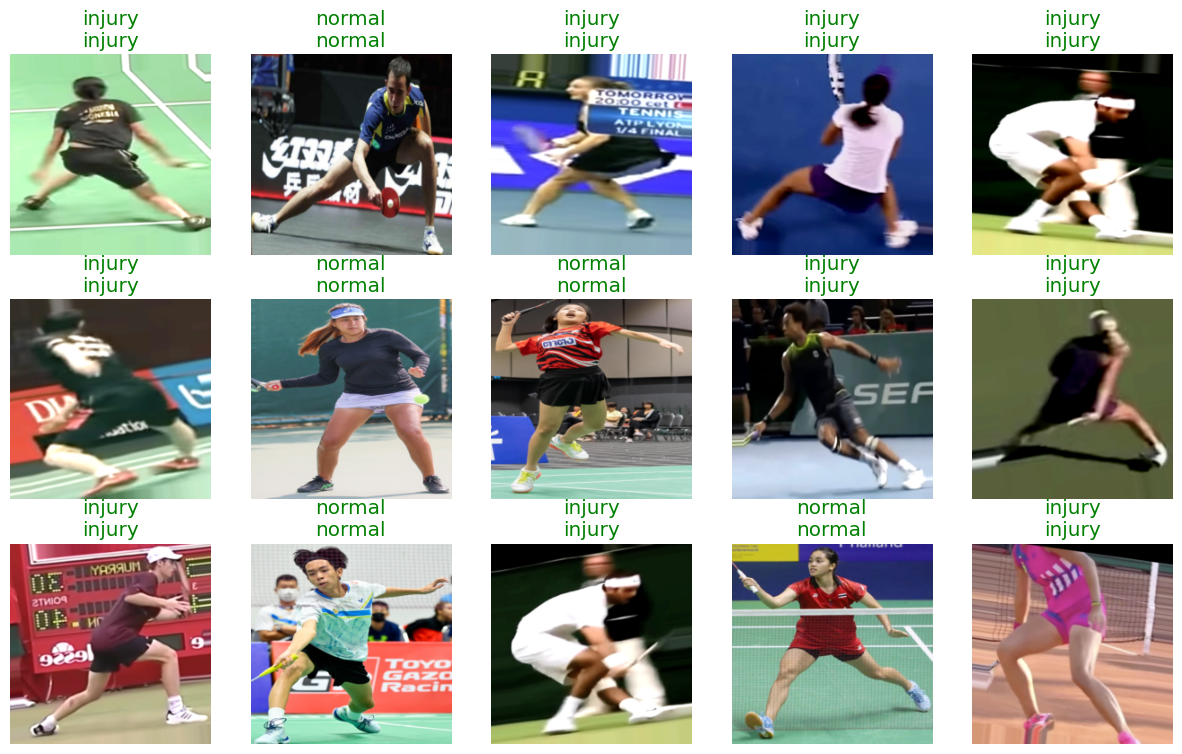

In [ ]:
learner.show_results(max_n=15,shuffle=True)

In [ ]:
learner.evaluluate()

AttributeError: ignored

Yahoo

In [11]:
learner.export("swinv1_t.pkl")

In [ ]:
from fastbook import *
from glob import glob
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

learn_inf = load_learner('/content/8_xresnet50_fastai_binary.pkl')

In [ ]:
tt=Image.open("/content/gdrive/MyDrive/Colab Notebooks/data/te/yahoo/n322.jpg").resize((224, 224))

In [ ]:
p=learn_inf.predict(tt)

In [12]:
p=load_learner('/content/swinv1_t.pkl')

Testing time: 53.236751079559326


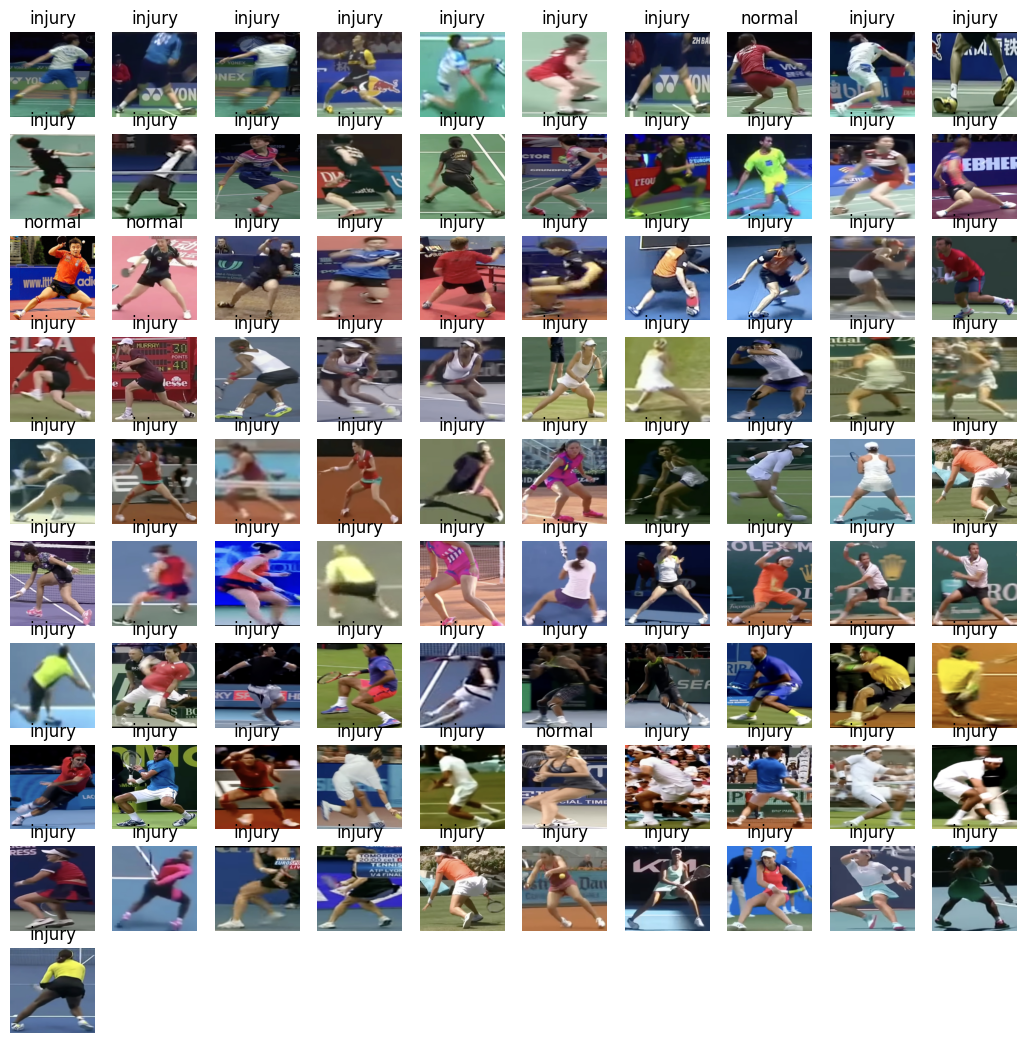

In [13]:
t2 = time.time()
plt.figure(figsize=(13,13))
jj=('/content/drive/MyDrive/data3/te/injury/')
# jj=('/content/gdrive/MyDrive/Colab Notebooks/data2/te/yahoo/')
# p = os.listdir('data/')
c=0
for i in os.listdir(jj)[:91]:
    plt.subplot(10,10,c)
    img = Image.open(jj+i).resize((200, 200))
    # img1 = cv2.resize(img,(50,50))
    # img1 = img1.reshape(1,-1)/255
    # img1=np.array (img1).flatten()
    # img1=img1.convert("L")
    pred_class, pred_idx, outputs =p.predict(img)
    plt.title(pred_class) if pred_class == "injury" else plt.title(pred_class ,weight='bold',color='red')
    #plt.title(outputs[1],loc='right',size='small',style='italic', weight='bold')
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
    #print(p)
print("Testing time:", time.time()-t2)
time_per_image = (time.time()-t2)/ c
print("Time per image:", time_per_image, "seconds")

In [14]:
t1 = time.time()
plt.figure(figsize=(13,13))
jj=('/content/drive/MyDrive/data3/te/normal/')
# jj=('/content/gdrive/MyDrive/Colab Notebooks/data2/te/yahoo/')
# p = os.listdir('data/')
c=0
for i in os.listdir(jj)[:98]:
    plt.subplot(10,10,c)
    img = Image.open(jj+i).convert('RGB').resize((200, 200))
    # img1 = cv2.resize(img,(50,50))
    # img1 = img1.reshape(1,-1)/255
    # img1=np.array (img1).flatten()
    # img1=img1.convert("L")
    pred_class, pred_idx, outputs =p.predict(img)
    plt.title(pred_class) if pred_class == "normal" else plt.title(pred_class ,weight='bold',color='red')
    #plt.title(outputs[1],loc='right',size='small',style='italic', weight='bold')
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
    #print(p)
print("Testing time:", time.time()-t1)
time_per_image = (time.time()-t1)/ c
print("Time per image:", time_per_image, "seconds")

Output hidden; open in https://colab.research.google.com to view.